<a href="https://colab.research.google.com/github/sarafelix25/eeg-ai-analysis/blob/main/eeg-ai-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install "decorator>=5.1"

In [ ]:
import mne

# Verifica a versão instalada
print(f"Versão do MNE: {mne.__version__}")

print("Sucesso! O MNE está pronto para uso.")

Versão do MNE: 1.13.2
Using default location ~/mne_data for sample...
Creating /root/mne_data
Fetching 1 file for the sample dataset ...


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m47s (1576.2 MB)
Dados de exemplo do MNE configurados na pasta: /root/mne_data/MNE-sample-data
Sucesso! O MNE está pronto para uso.


In [ ]:
import mne

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from pathlib import Path

caminhos_edf = (Path.cwd() / "chb24_01.edf", Path.cwd().parent / "chb24_01.edf")
arquivo_edf = next((caminho for caminho in caminhos_edf if caminho.is_file()), None)
if arquivo_edf is None:
    raise FileNotFoundError("Não foi possível localizar chb24_01.edf na pasta do notebook ou na raiz do projeto.")

raw = mne.io.read_raw_edf(arquivo_edf, preload=True)
raw

Extracting EDF parameters from chb24_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_7433/2877399466.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(arquivo_edf, preload=True)


<RawEDF | chb24_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [ ]:
print(raw.info)
print(raw.ch_names)
print(f"Taxa de amostragem: {raw.info['sfreq']} Hz")

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2074-01-25 16:26:28 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Taxa de amostragem: 256.0 Hz


os códigos FP, F, P, T, C são códigos neuro encefalograma que significam:
F = Frontal
FP = frontal polar
P = parietal
T = temporal
C = hospital

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


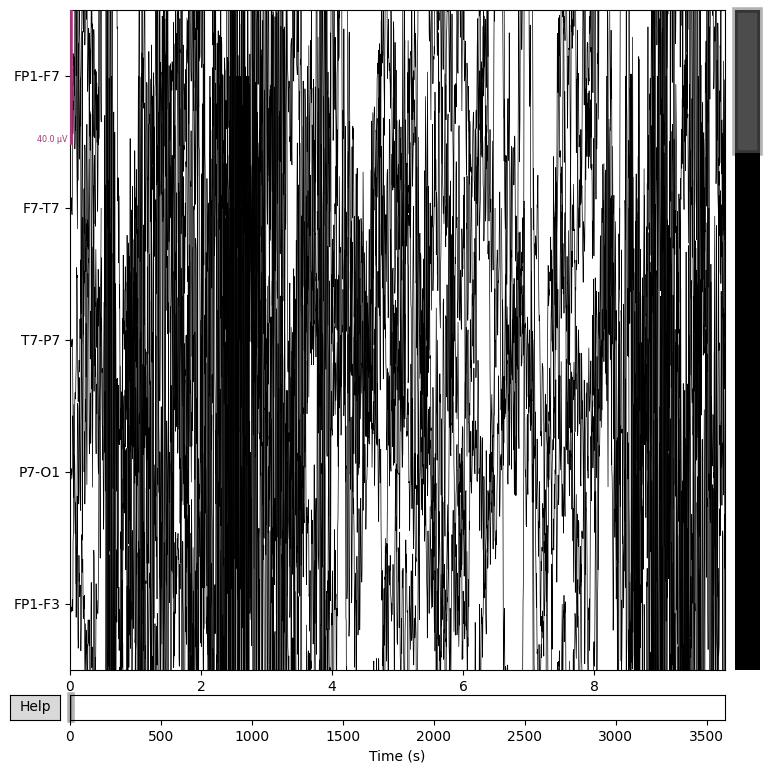

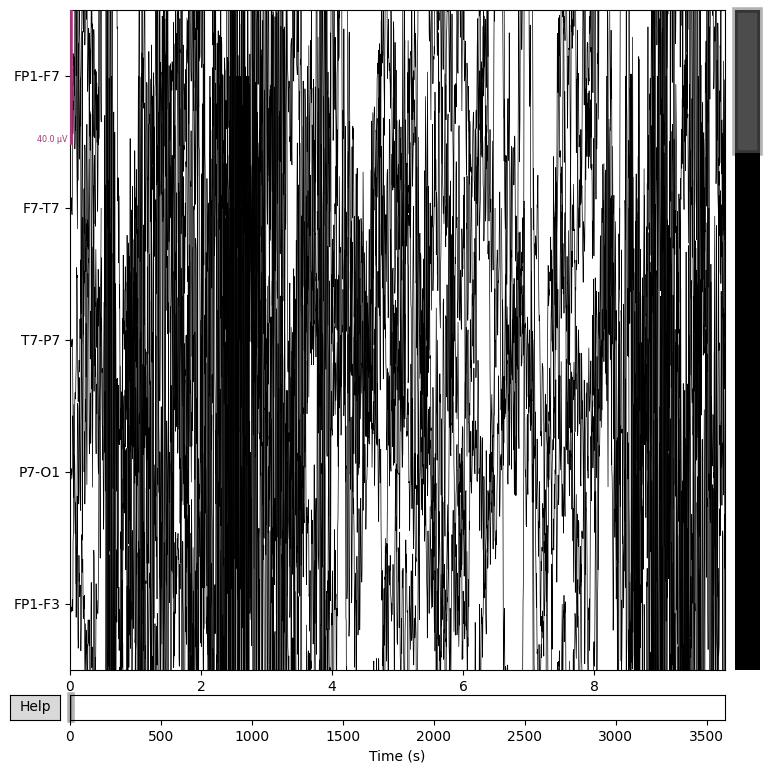

In [ ]:
raw.plot(duration=10, n_channels=5)

In [ ]:
data = raw.get_data()
data.shape

(23, 921600)

In [ ]:
print("Número de canais:", data.shape[0])
print("Número de amostras:", data.shape[1])

Número de canais: 23
Número de amostras: 921600
